## Importing Modules

In [4]:
import pandas as pd
import numpy as np

## Loading Data

In [5]:
df=pd.read_csv('/home/user/Desktop/Employee Salary Prediction Project/data/raw/Salary_Data.csv')

In [6]:
df

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0
...,...,...,...,...,...,...
6699,49.0,Female,PhD,Director of Marketing,20.0,200000.0
6700,32.0,Male,High School,Sales Associate,3.0,50000.0
6701,30.0,Female,Bachelor's Degree,Financial Manager,4.0,55000.0
6702,46.0,Male,Master's Degree,Marketing Manager,14.0,140000.0


In [7]:
## statistical analysis
df.describe()

,Age,Years of Experience,Salary
count,6702.000000,6701.000000,6699.000000
mean,33.620859,8.094687,115326.964771
std,7.614633,6.059003,52786.183911
min,21.000000,0.000000,350.000000
25%,28.000000,3.000000,70000.000000
50%,32.000000,7.000000,115000.000000
75%,38.000000,12.000000,160000.000000
max,62.000000,34.000000,250000.000000


In [8]:
## checking datatypes
df.dtypes

Age                    float64
Gender                  object
Education Level         object
Job Title               object
Years of Experience    float64
Salary                 float64
dtype: object

## Handling missing Data

In [9]:
## counts each column's missing data
df.isnull().sum()

Age                    2
Gender                 2
Education Level        3
Job Title              2
Years of Experience    3
Salary                 5
dtype: int64

In [10]:
numerical_columns=df.select_dtypes(include=np.number).columns
numerical_columns

Index(['Age', 'Years of Experience', 'Salary'], dtype='object')

In [11]:
categorical_columns=df.select_dtypes(include='object').columns
categorical_columns

Index(['Gender', 'Education Level', 'Job Title'], dtype='object')

In [12]:
## Imputation of columns
for col in numerical_columns:
    df[col].fillna(df[col].mean(), inplace=True)
for col in categorical_columns:
    df[col].fillna(df[col].mode()[0],inplace=True)
df.isnull().sum()

/tmp/ipykernel_9916/1746956227.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)
/tmp/ipykernel_9916/1746956227.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usin

Age                    0
Gender                 0
Education Level        0
Job Title              0
Years of Experience    0
Salary                 0
dtype: int64

In [13]:
## checking duplicates
df.duplicated().sum()

np.int64(4912)

In [14]:
## dropping duplicates
df.drop_duplicates(inplace=True)

In [15]:
df.shape

(1792, 6)

## Data Formatting

In [16]:
df['Age'].unique()

array([32.        , 28.        , 45.        , 36.        , 52.        ,
       29.        , 42.        , 31.        , 26.        , 38.        ,
       48.        , 35.        , 40.        , 27.        , 44.        ,
       33.        , 39.        , 25.        , 51.        , 34.        ,
       47.        , 30.        , 41.        , 37.        , 24.        ,
       43.        , 50.        , 46.        , 49.        , 23.        ,
       53.        , 33.62085944, 61.        , 57.        , 62.        ,
       55.        , 56.        , 54.        , 60.        , 58.        ,
       22.        , 21.        ])

In [17]:
## Age column has float values, we can convert them to integer values using floor function 
import math
df['Age']=df['Age'].apply(lambda x: math.floor(x))
df['Age'].unique()

array([32, 28, 45, 36, 52, 29, 42, 31, 26, 38, 48, 35, 40, 27, 44, 33, 39,
       25, 51, 34, 47, 30, 41, 37, 24, 43, 50, 46, 49, 23, 53, 61, 57, 62,
       55, 56, 54, 60, 58, 22, 21])

In [18]:
df['Gender'].unique()

array(['Male', 'Female', 'Other'], dtype=object)

In [19]:
# df['Gender']=df['Gender'].replace({
#     'Male':0,
#     'Female':1,
#     'Other':2,
# })

In [20]:
df['Gender'].value_counts()

Gender
Male      970
Female    815
Other       7
Name: count, dtype: int64

In [21]:
df['Education Level'].unique()

array(["Bachelor's", "Master's", 'PhD', "Bachelor's Degree",
       "Master's Degree", 'High School', 'phD'], dtype=object)

In [22]:
df['Education Level'] = df['Education Level'].replace({
    "Bachelor's Degree": "Bachelor's",
    "Master's Degree": "Master's",
    "phD": "PhD"
})
df['Education Level'].unique()

array(["Bachelor's", "Master's", 'PhD', 'High School'], dtype=object)

In [23]:
# df['Education Level']=df['Education Level'].replace(
#     { 
#         'High School': 1 ,
#         "Bachelor's": 2,
#         "Master's": 3,
#         'PhD': 4
#     })

In [24]:
df['Job Title'].unique()

array(['Software Engineer', 'Data Analyst', 'Senior Manager',
       'Sales Associate', 'Director', 'Marketing Analyst',
       'Product Manager', 'Sales Manager', 'Marketing Coordinator',
       'Senior Scientist', 'Software Developer', 'HR Manager',
       'Financial Analyst', 'Project Manager', 'Customer Service Rep',
       'Operations Manager', 'Marketing Manager', 'Senior Engineer',
       'Data Entry Clerk', 'Sales Director', 'Business Analyst',
       'VP of Operations', 'IT Support', 'Recruiter', 'Financial Manager',
       'Social Media Specialist', 'Software Manager', 'Junior Developer',
       'Senior Consultant', 'Product Designer', 'CEO', 'Accountant',
       'Data Scientist', 'Marketing Specialist', 'Technical Writer',
       'HR Generalist', 'Project Engineer', 'Customer Success Rep',
       'Sales Executive', 'UX Designer', 'Operations Director',
       'Network Engineer', 'Administrative Assistant',
       'Strategy Consultant', 'Copywriter', 'Account Manager',
      

In [25]:
df['Job Title'] = (
    df['Job Title']
    .str.strip()
    .str.lower()
)

In [26]:
df['Job Title'] = df['Job Title'].replace({
    'juniour hr generalist': 'junior hr generalist',
    'juniour hr coordinator': 'junior hr coordinator',
    'social m': 'social media specialist',
    'social media man': 'social media manager'
})

In [27]:
df['Job Title'] = df['Job Title'].str.replace(
    'front end', 'front-end', regex=False
)

df['Job Title'] = df['Job Title'].str.replace(
    'back end', 'back-end', regex=False
)

In [28]:
def get_seniority(title):

    title = title.lower()

    if any(x in title for x in ['ceo', 'cto', 'chief', 'vp']):
        return 'Executive'

    elif 'director' in title:
        return 'Director'

    elif any(x in title for x in ['senior', 'principal']):
        return 'Senior'

    elif 'junior' in title:
        return 'Junior'

    elif 'manager' in title:
        return 'Manager'

    else:
        return 'Mid-Level'

In [29]:
df['seniority'] = df['Job Title'].apply(get_seniority)

In [30]:
df['seniority'].value_counts()

seniority
Mid-Level    737
Manager      383
Senior       367
Junior       182
Executive    123
Name: count, dtype: int64

In [31]:
# df['seniority']=df['seniority'].replace({
#     'Manager':5,
#     'Executive': 4,
#     'Director': 3,
#     'Senior': 2,
#     'Mid-Level': 1,
#     'Junior': 0
# })

In [32]:
def get_job_function(title):

    title = title.lower()

    if any(x in title for x in [
        'data scientist',
        'data analyst',
        'data engineer',
        'business intelligence',
        'chief data'
    ]):
        return 'Data & AI'

    elif any(x in title for x in [
        'software',
        'developer',
        'programmer',
        'network',
        'it support',
        'technical support',
        'architect',
        'cto'
    ]):
        return 'Software & IT'

    elif any(x in title for x in [
        'marketing',
        'social media',
        'copywriter',
        'public relations',
        'content',
        'advertising'
    ]):
        return 'Marketing & Communications'

    elif any(x in title for x in [
        'sales',
        'account executive',
        'account manager',
        'business development'
    ]):
        return 'Sales & Business'

    elif any(x in title for x in [
        'financial',
        'finance',
        'accountant'
    ]):
        return 'Finance & Accounting'

    elif any(x in title for x in [
        'human resources',
        'human resource',
        'hr ',
        'recruiter',
        'human capital'
    ]):
        return 'Human Resources'

    elif any(x in title for x in [
        'operations',
        'supply chain'
    ]):
        return 'Operations & Supply Chain'

    elif any(x in title for x in [
        'product',
        'designer',
        'ux',
        'graphic'
    ]):
        return 'Product & Design'

    elif any(x in title for x in [
        'research',
        'scientist'
    ]):
        return 'Research & Science'

    elif any(x in title for x in [
        'customer',
        'help desk'
    ]):
        return 'Customer Service'

    elif any(x in title for x in [
        'project',
        'strategy',
        'consultant'
    ]):
        return 'Project & Consulting'

    else:
        return 'Administration & Other'

In [33]:
df['job_function'] = df['Job Title'].apply(get_job_function)

In [34]:
df['job_function'].value_counts()

job_function
Software & IT                 676
Marketing & Communications    206
Administration & Other        157
Data & AI                     156
Sales & Business              133
Project & Consulting          121
Human Resources               108
Product & Design               89
Finance & Accounting           66
Operations & Supply Chain      45
Research & Science             25
Customer Service               10
Name: count, dtype: int64

In [35]:
# df['job_function']=df['job_function'].replace({
#     'Software & IT':0,
#     'Marketing & Communications':1,
#     'Administration & Other':2,
#     'Data & AI':3,
#     'Sales & Business':4,
#     'Project & Consulting':5,
#     'Human Resources':6,
#     'Product & Design':7,
#     'Finance & Accounting':8,
#     'Operations & Supply Chain':9,
#     'Research & Science':10,
#     'Customer Service':11
# })

In [36]:
pd.crosstab(
    df['job_function'],
    df['seniority']
)

seniority,Executive,Junior,Manager,Mid-Level,Senior
job_function,,,,,
Administration & Other,2,4,2,136,13
Customer Service,0,1,3,6,0
Data & AI,1,4,0,132,19
Finance & Accounting,1,10,28,14,13
Human Resources,0,41,14,16,37
Marketing & Communications,0,23,100,48,35
Operations & Supply Chain,1,10,23,2,9
Product & Design,0,6,53,18,12
Project & Consulting,0,3,8,2,108


In [37]:
df[['Job Title', 'job_function', 'seniority']].drop_duplicates().sort_values(
    'job_function'
)

,Job Title,job_function,seniority
5645,delivery driver,Administration & Other,Mid-Level
43,administrative assistant,Administration & Other,Mid-Level
20,business analyst,Administration & Other,Mid-Level
18,data entry clerk,Administration & Other,Mid-Level
17,senior engineer,Administration & Other,Senior
...,...,...,...
170,director of finance,Software & IT,Executive
4,director,Software & IT,Executive
188,director of sales and marketing,Software & IT,Executive
200,director of human capital,Software & IT,Executive


In [38]:
df = df.drop(columns=['Job Title'])

In [39]:
df

,Age,Gender,Education Level,Years of Experience,Salary,seniority,job_function
0,32,Male,Bachelor's,5.0,90000.0,Mid-Level,Software & IT
1,28,Female,Master's,3.0,65000.0,Mid-Level,Data & AI
2,45,Male,PhD,15.0,150000.0,Senior,Administration & Other
3,36,Female,Bachelor's,7.0,60000.0,Mid-Level,Sales & Business
4,52,Male,Master's,20.0,200000.0,Executive,Software & IT
...,...,...,...,...,...,...,...
6623,43,Female,Master's,15.0,150000.0,Manager,Marketing & Communications
6624,27,Male,High School,2.0,40000.0,Manager,Sales & Business
6625,33,Female,Bachelor's,8.0,80000.0,Executive,Software & IT
6628,37,Male,Bachelor's,7.0,90000.0,Executive,Software & IT


## Exploratory Data Analysis

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt

In [41]:
# correlation=numerical_columns.corr()
# sns.heatmap(correlation)

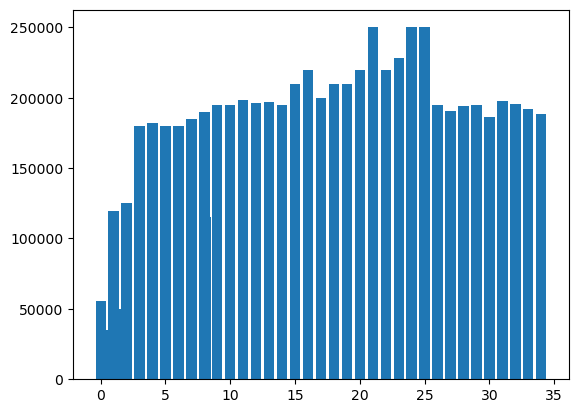

In [42]:
plt.bar(df['Years of Experience'],df['Salary'])
plt.show()

<Axes: xlabel='Salary', ylabel='Count'>

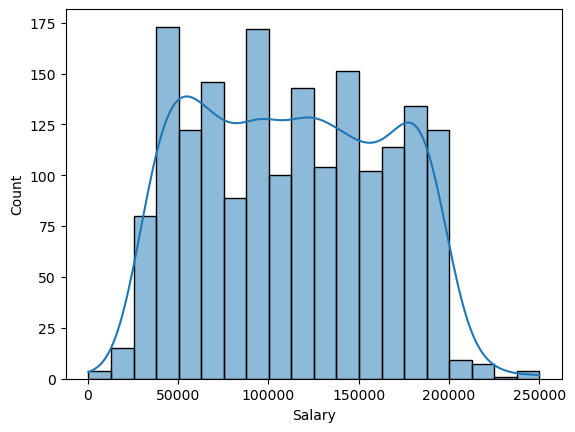

In [43]:
sns.histplot(df['Salary'], bins=20,kde=True)

<Axes: xlabel='seniority', ylabel='Salary'>

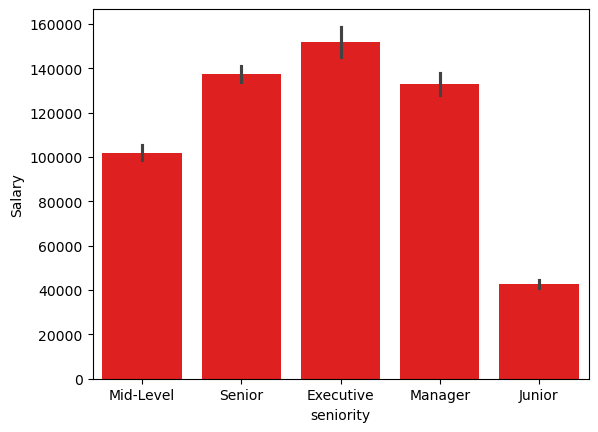

In [44]:
sns.barplot(x='seniority', y='Salary', data=df,color='red')

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
 [Text(0, 0, 'Software & IT'),
  Text(1, 0, 'Data & AI'),
  Text(2, 0, 'Administration & Other'),
  Text(3, 0, 'Sales & Business'),
  Text(4, 0, 'Marketing & Communications'),
  Text(5, 0, 'Product & Design'),
  Text(6, 0, 'Research & Science'),
  Text(7, 0, 'Human Resources'),
  Text(8, 0, 'Finance & Accounting'),
  Text(9, 0, 'Project & Consulting'),
  Text(10, 0, 'Customer Service'),
  Text(11, 0, 'Operations & Supply Chain')])

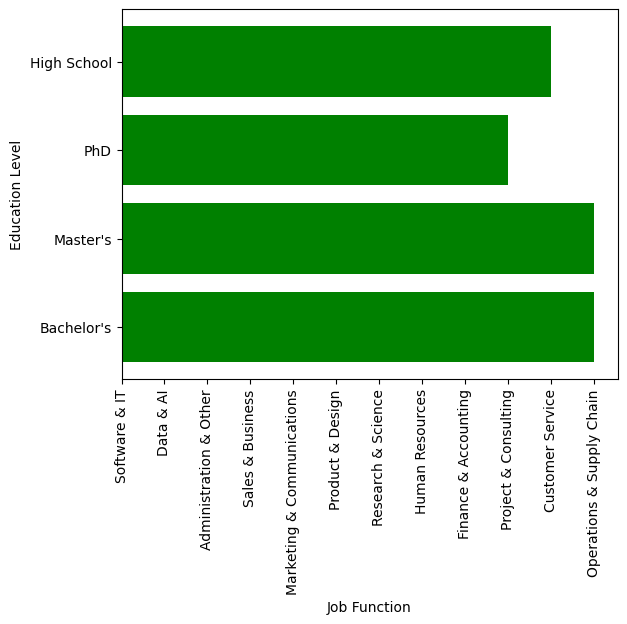

In [45]:
plt.barh(df['Education Level'], df['job_function'],color='green')
plt.xlabel('Job Function')
plt.ylabel('Education Level')
plt.xticks(rotation=90)


In [46]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
cat_cols=['Gender','Education Level','job_function','seniority']
for col in cat_cols: 
    df[col]=le.fit_transform(df[col])
df

,Age,Gender,Education Level,Years of Experience,Salary,seniority,job_function
0,32,1,0,5.0,90000.0,3,11
1,28,0,2,3.0,65000.0,3,2
2,45,1,3,15.0,150000.0,4,0
3,36,0,0,7.0,60000.0,3,10
4,52,1,2,20.0,200000.0,0,11
...,...,...,...,...,...,...,...
6623,43,0,2,15.0,150000.0,2,5
6624,27,1,1,2.0,40000.0,2,10
6625,33,0,0,8.0,80000.0,0,11
6628,37,1,0,7.0,90000.0,0,11


In [ ]:
df.to_csv('cleaned_salary_data.csv', index=False)